# 05 — Evaluation & Interpretability

**Project:** Forecasting the Effects of Exchange Rate Fluctuations on US Trade Flows  
**Phase:** CRISP-DM 5 — Evaluation  
**Author:** Francisco Giordano Rigon

---

## Purpose

This notebook answers the central research question of the thesis:

> **How do exchange rate fluctuations affect US bilateral trade flows with Canada, Mexico, and Brazil?**

The 72 models in `04_modeling.ipynb` predict *how much* trade will occur.  
This notebook extracts *why* — specifically the role of exchange rate variables.

## Structure

1. Setup — load models and results
2. Load Data and Models
3. Naïve Baseline — minimum bar (last observed value)
4. Statistical Significance Tests
   4.1 Ljung-Box — ARIMA residual diagnostics
   4.2 Friedman — overall algorithm difference
   4.3 Wilcoxon + Bonferroni — pairwise comparison
   4.4 Diebold-Mariano — forecasting-specific significance
5. Feature Importance — which of the 73 variables matter most (RF and LightGBM)
6. SHAP Analysis — direction and magnitude of each variable's effect on predictions
7. Exchange Rate Focus — isolate FX and REER effects across countries and sectors
8. ARIMA vs ML gap — what the exchange rate features add beyond series history
9. Sector Sensitivity — which sectors respond most to exchange rate movements
10. Summary for thesis

---
## 1. Setup

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
from pathlib import Path

import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Paths ---
PROC    = Path('../data/processed')
MODELS  = Path('../models')
RESULTS = Path('../results')
FIGS    = RESULTS / 'figures' / 'evaluation'
FIGS.mkdir(parents=True, exist_ok=True)

# --- Config ---
PARTNERS = {'CAN': 'Canada', 'MEX': 'Mexico', 'BRA': 'Brazil'}
TARGETS  = [
    'exports_total', 'exports_commodities', 'exports_manufactured_goods', 'exports_high-tech',
    'imports_total', 'imports_commodities', 'imports_manufactured_goods', 'imports_high-tech',
]
TRAIN_END  = '2021-12-01'
TEST_START = '2022-01-01'

# Exchange rate and REER column prefixes (the thesis focus)
FX_COLS   = ['FX_USD_CAD', 'FX_USD_MXN', 'FX_USD_BRL']
REER_COLS = ['REER_USA', 'REER_CAN', 'REER_MEX', 'REER_BRA']

print('Setup complete.')

Setup complete.


---
## 2. Load Data and Models

In [30]:
# --- Load processed datasets ---
datasets = {}
for iso in PARTNERS:
    df = pd.read_csv(PROC / f'dataset_{iso.lower()}.csv', index_col=0, parse_dates=True)
    datasets[iso] = df

# --- Load all 48 ML models (RF + LightGBM) ---
rf_models   = {}
lgbm_models = {}

for iso in PARTNERS:
    for target in TARGETS:
        fname = MODELS / 'random_forest' / f'rf_{iso.lower()}_{target}.pkl'
        with open(fname, 'rb') as f:
            rf_models[(iso, target)] = pickle.load(f)['model']

        fname = MODELS / 'lightgbm' / f'lgbm_{iso.lower()}_{target}.pkl'
        with open(fname, 'rb') as f:
            lgbm_models[(iso, target)] = pickle.load(f)['model']

# --- Load combined metrics ---
df_all = pd.read_csv(RESULTS / 'forecasts' / 'metrics_all.csv')

print(f'Datasets: {list(datasets.keys())}')
print(f'RF models: {len(rf_models)}')
print(f'LightGBM models: {len(lgbm_models)}')
print(f'Metrics table: {df_all.shape}')

Datasets: ['CAN', 'MEX', 'BRA']
RF models: 24
LightGBM models: 24
Metrics table: (72, 6)


---
## 3. Naïve Baseline

Before evaluating how sophisticated the models are, we need a sanity check:

> **Are they better than doing nothing?**

The **Naïve forecast** predicts that next month's trade will equal this month's value — no model, no features, no learning. It is the minimum acceptable bar. If ARIMA, RF or LightGBM cannot consistently beat this, the models add no value beyond trivial extrapolation.

---

> **Methodological note — forecasting horizon:**
> - **ARIMA**: *1-step-ahead, walk-forward* — re-trains at each of the 36 test months and predicts only one month at a time. Strictly simulates real-world usage.
> - **RF / LightGBM**: *36-step direct* — trained once on 2010–2021, then predicts all 36 test months in a single call using the known feature values.
>
> These are different forecasting strategies. The comparison is intentional and documented as methodological scope: ARIMA is evaluated under a stricter protocol (walk-forward), while ML models leverage a richer feature set to compensate.
>
> **Important for interpretation:** the Naïve baseline has a structural advantage — it observes the actual value from the previous month at each prediction step. RF and LightGBM, by contrast, produce all 36 forecasts in a single pass without access to any test-period actuals. A lower Naïve MAPE does not mean the models are worse; it reflects the asymmetric information available to each forecaster. This limitation is standard in direct multi-step forecasting and is documented as methodological scope.

In [31]:
# --- Naïve Baseline ---
# Prediction rule: log_trade[t] = log_trade[t-1]  (last observed value)
# Applied to the same test window (Jan 2022 – Dec 2024) as all other models.

naive_rows = []

for iso in PARTNERS:
    df = datasets[iso]
    for target in TARGETS:
        log_col    = 'log_' + target
        log_series = df[log_col].dropna()

        actuals    = log_series[log_series.index >= TEST_START].values
        last_train = float(log_series[log_series.index <= TRAIN_END].iloc[-1])

        # preds[0] = last training value; preds[t] = actuals[t-1] for t >= 1
        preds  = np.concatenate([[last_train], actuals[:-1]])
        errors = actuals - preds

        mae  = float(np.mean(np.abs(errors)))
        rmse = float(np.sqrt(np.mean(errors ** 2)))
        mape = float(np.mean(np.abs(errors / actuals)) * 100)

        naive_rows.append({
            'country':   iso,
            'target':    target,
            'algorithm': 'Naive',
            'MAE':  round(mae,  4),
            'RMSE': round(rmse, 4),
            'MAPE': round(mape, 4),
        })

df_naive   = pd.DataFrame(naive_rows)
df_all_ext = pd.concat([df_all, df_naive], ignore_index=True)

summary = (
    df_all_ext
    .groupby('algorithm')['MAPE']
    .agg(Mean='mean', Min='min', Max='max')
    .round(4)
    .sort_values('Mean')
)

print('=== Mean MAPE — All Algorithms vs Naïve Baseline ===')
print(summary.to_string())
print()
naive_mean = df_naive['MAPE'].mean()
for algo in sorted(df_all['algorithm'].unique()):
    m    = df_all[df_all['algorithm'] == algo]['MAPE'].mean()
    beat = 'beats' if m < naive_mean else 'does NOT beat'
    print(f'  {algo:<15}: {m:.4f}%  ->  {beat} Naive ({naive_mean:.4f}%)')

=== Mean MAPE — All Algorithms vs Naïve Baseline ===
                Mean     Min     Max
algorithm                           
Naive         0.3154  0.2125  0.5479
RandomForest  0.9381  0.5615  1.5012
LightGBM      1.0276  0.4767  1.9279
ARIMA         1.4143  0.3952  3.4792

  ARIMA          : 1.4143%  ->  does NOT beat Naive (0.3154%)
  LightGBM       : 1.0276%  ->  does NOT beat Naive (0.3154%)
  RandomForest   : 0.9381%  ->  does NOT beat Naive (0.3154%)


---
## 4. Statistical Significance Tests

Comparing average MAPE values is an observation, not a statistical conclusion.  Three tests determine whether the differences are significant.

| Test | What it answers |
|------|----------------|
| **4.1 Ljung-Box** | Are the ARIMA residuals white noise? (model adequacy check before comparison) |
| **4.2 Friedman** | Are the three algorithms different at all? (prerequisite for pairwise tests) |
| **4.3 Wilcoxon + Bonferroni** | Which pairs differ? (non-parametric, corrected for 3 comparisons) |
| **4.4 Diebold-Mariano** | Is the accuracy difference significant using the full error sequence? (forecasting standard) |

H₀ for all tests: the algorithms have equal predictive accuracy.

In [32]:
from scipy.stats import friedmanchisquare, wilcoxon
from scipy.stats import t as t_dist
from statsmodels.tsa.arima.model import ARIMA as ARIMAModel
from itertools import combinations

# --- Helper: identify feature columns (excludes all trade target columns) ---
def get_feature_cols(df):
    exclude = [c for c in df.columns if 'exports' in c or 'imports' in c]
    return [c for c in df.columns if c not in exclude]

# --- Reproduce train/test split (same logic as 04_modeling.ipynb) ---
def get_train_test_ml(df, target):
    feat_cols  = get_feature_cols(df)
    log_target = 'log_' + target
    clean      = df[feat_cols + [log_target]].dropna()
    X = clean[feat_cols]
    y = clean[log_target]
    return (
        X[X.index <= TRAIN_END],
        X[X.index >= TEST_START],
        y[y.index <= TRAIN_END],
        y[y.index >= TEST_START],
    )

# --- Reconstruct RF and LightGBM error sequences (fast: one predict() call each) ---
pred_errors = {'RF': {}, 'LightGBM': {}, 'ARIMA': {}}

for iso in PARTNERS:
    df = datasets[iso]
    for target in TARGETS:
        _, X_test, _, y_test = get_train_test_ml(df, target)

        rf_preds           = rf_models[(iso, target)].predict(X_test)
        lgbm_preds         = lgbm_models[(iso, target)].predict(X_test)
        pred_errors['RF'][(iso, target)]       = y_test.values - rf_preds
        pred_errors['LightGBM'][(iso, target)] = y_test.values - lgbm_preds

n_ok = len(pred_errors['RF'])
print(f'ML errors computed for {n_ok} series.')
print(f'Error length per series: {pred_errors["RF"][("CAN","exports_total")].shape[0]} steps')

ML errors computed for 24 series.
Error length per series: 36 steps


In [33]:
# --- ARIMA walk-forward re-run ---
# Needed for Diebold-Mariano test (requires the 36-step error sequence).
# Loads the best order from the saved .pkl; re-fits one model per test month.
# ~5-10 minutes total (864 ARIMA fits across 24 series).

def arima_error_sequence(df, target, best_order):
    diff_col = 'diff_log_' + target
    log_col  = 'log_' + target
    series   = df[[diff_col, log_col]].dropna()
    train_s  = series[series.index <= TRAIN_END]
    test_s   = series[series.index >= TEST_START]

    last_log = float(df[log_col].dropna().loc[:TRAIN_END].iloc[-1])
    history  = list(train_s[diff_col].values)

    preds_log = []
    prev      = last_log

    for t in range(len(test_s)):
        try:
            res    = ARIMAModel(history, order=best_order).fit()
            fc     = res.forecast(steps=1)
            d_pred = float(fc[0]) if hasattr(fc, '__len__') else float(fc)
        except Exception:
            d_pred = 0.0

        curr = prev + d_pred
        preds_log.append(curr)
        prev = curr
        history.append(float(test_s[diff_col].iloc[t]))

    log_s       = df[log_col].dropna()
    actuals_log = log_s[log_s.index >= TEST_START].values[:len(test_s)]
    return actuals_log - np.array(preds_log)


print('Running ARIMA walk-forward for error sequences (~5-10 min)...\n')
for iso in PARTNERS:
    df = datasets[iso]
    for target in TARGETS:
        pkl_path = MODELS / 'arima' / f'arima_{iso.lower()}_{target}.pkl'
        with open(pkl_path, 'rb') as fh:
            arima_data = pickle.load(fh)

        if 'predictions_log' in arima_data and 'actuals_log' in arima_data:
            p = np.array(arima_data['predictions_log'])
            a = np.array(arima_data['actuals_log'])
            pred_errors['ARIMA'][(iso, target)] = a - p
        else:
            best_order = arima_data.get('order', (1, 0, 1))
            pred_errors['ARIMA'][(iso, target)] = arima_error_sequence(
                df, target, best_order
            )

        print(f'  {iso} {target} ✓')

print('\nARIMA error sequences ready.')

Running ARIMA walk-forward for error sequences (~5-10 min)...

  CAN exports_total ✓
  CAN exports_commodities ✓
  CAN exports_manufactured_goods ✓
  CAN exports_high-tech ✓
  CAN imports_total ✓
  CAN imports_commodities ✓
  CAN imports_manufactured_goods ✓
  CAN imports_high-tech ✓
  MEX exports_total ✓
  MEX exports_commodities ✓
  MEX exports_manufactured_goods ✓
  MEX exports_high-tech ✓
  MEX imports_total ✓
  MEX imports_commodities ✓
  MEX imports_manufactured_goods ✓
  MEX imports_high-tech ✓
  BRA exports_total ✓
  BRA exports_commodities ✓
  BRA exports_manufactured_goods ✓
  BRA exports_high-tech ✓
  BRA imports_total ✓
  BRA imports_commodities ✓
  BRA imports_manufactured_goods ✓
  BRA imports_high-tech ✓

ARIMA error sequences ready.


### 4.1 ARIMA Residual Diagnostics — Ljung-Box Test

Before comparing ARIMA against other models, we check whether the ARIMA itself is well-specified.

**The idea in plain language:**
After the ARIMA is fitted on the training data, the *residuals* are what is left over — the part of the data the model could not explain. In a good model, the residuals should look like pure random noise: no repeating pattern, no correlation between consecutive months.

If the residuals still contain a pattern (autocorrelation), the model "left something on the table" and the forecasts may be biased.

**The Ljung-Box test** formalises this:

| Result | Meaning |
|--------|---------|
| p ≥ 0.05 | Residuals are white noise → ARIMA is well-specified ✓ |
| p < 0.05 | Residuals still carry structure → ARIMA may be under-fitted ✗ |

The **ACF plot** (autocorrelation function) visualises the same thing: if all bars fall within the shaded confidence band, residuals are random.

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Re-fit each ARIMA on the full training set to obtain in-sample residuals.
# One fit per series (fast: ~5 seconds total).

in_sample_resid = {}
ljung_rows      = []

for iso in PARTNERS:
    df = datasets[iso]
    for target in TARGETS:
        diff_col = 'diff_log_' + target
        series   = df[diff_col].dropna()
        train_s  = series[series.index <= TRAIN_END].values

        pkl_path = MODELS / 'arima' / f'arima_{iso.lower()}_{target}.pkl'
        with open(pkl_path, 'rb') as fh:
            arima_data = pickle.load(fh)
        best_order = arima_data.get('order', (1, 0, 1))

        try:
            result    = ARIMAModel(train_s, order=best_order).fit()
            residuals = result.resid
        except Exception as e:
            print(f'  Warning: {iso} {target}: {e}')
            residuals = np.zeros(len(train_s))

        in_sample_resid[(iso, target)] = residuals

        lb   = acorr_ljungbox(residuals, lags=[10], return_df=True)
        stat = float(lb['lb_stat'].values[0])
        pval = float(lb['lb_pvalue'].values[0])

        ljung_rows.append({
            'country':      iso,
            'target':       target,
            'ARIMA order':  str(best_order),
            'LB stat':      round(stat, 3),
            'p-value':      round(pval, 4),
            'White noise?': 'yes' if pval >= 0.05 else 'NO',
        })

df_ljung = pd.DataFrame(ljung_rows)
n_ok     = (df_ljung['p-value'] >= 0.05).sum()
n_bad    = 24 - n_ok

print('=== Ljung-Box Test — ARIMA In-Sample Residuals (lag = 10) ===')
print('H0: residuals are white noise | p >= 0.05 -> ARIMA is well-specified')
print()
print(df_ljung.to_string(index=False))
print()
print(f'Well-specified (p >= 0.05) : {n_ok} / 24 series')
print(f'Residual autocorrelation   : {n_bad} / 24 series')

=== Ljung-Box Test — ARIMA In-Sample Residuals (lag = 10) ===
H0: residuals are white noise | p >= 0.05 -> ARIMA is well-specified

country                     target ARIMA order  LB stat  p-value White noise?
    CAN              exports_total   (2, 0, 2)   13.491   0.1975          yes
    CAN        exports_commodities   (2, 1, 3)   31.000   0.0006           NO
    CAN exports_manufactured_goods   (3, 0, 3)   14.933   0.1345          yes
    CAN          exports_high-tech   (3, 0, 3)   15.221   0.1242          yes
    CAN              imports_total   (3, 0, 3)   22.098   0.0146           NO
    CAN        imports_commodities   (2, 0, 2)   15.568   0.1127          yes
    CAN imports_manufactured_goods   (3, 0, 3)   12.625   0.2454          yes
    CAN          imports_high-tech   (3, 0, 3)   10.931   0.3629          yes
    MEX              exports_total   (1, 0, 2)    2.543   0.9902          yes
    MEX        exports_commodities   (2, 0, 1)    6.855   0.7390          yes
    MEX ex

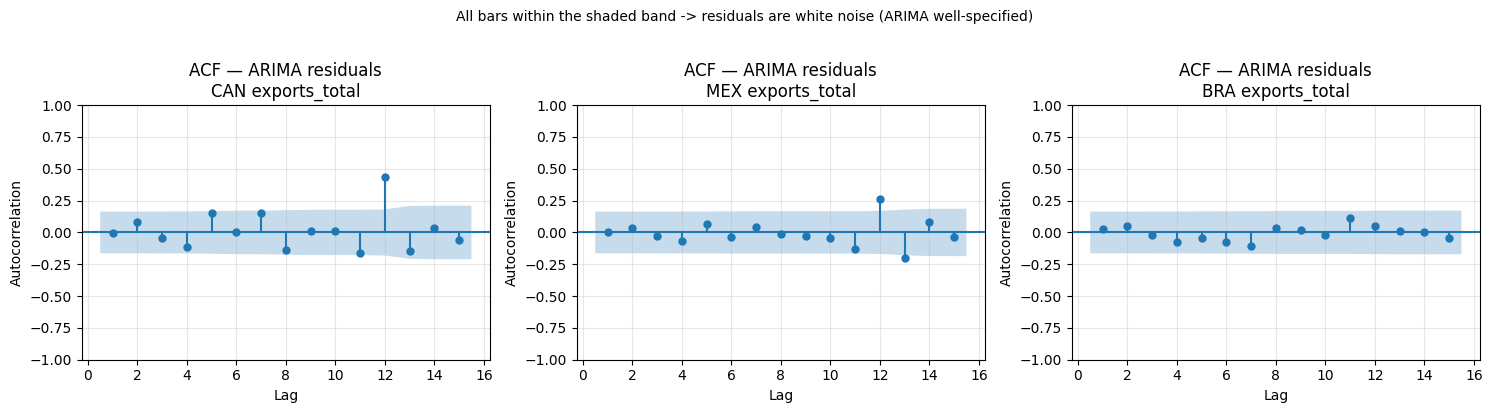

Saved: results/figures/evaluation/arima_residuals_acf.png


In [35]:
# --- ACF plots for exports_total (one per country) ---
sample_target = 'exports_total'
fig, axes     = plt.subplots(1, 3, figsize=(15, 4))

for ax, iso in zip(axes, PARTNERS):
    resid = in_sample_resid.get((iso, sample_target), np.zeros(10))
    plot_acf(resid, lags=15, ax=ax, zero=False, alpha=0.05)
    ax.set_title(f'ACF — ARIMA residuals\n{iso} {sample_target}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.grid(alpha=0.3)

fig.suptitle(
    'All bars within the shaded band -> residuals are white noise (ARIMA well-specified)',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(FIGS / 'arima_residuals_acf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/arima_residuals_acf.png')

In [36]:
# --- 3.1 Friedman Test ---
# Non-parametric repeated-measures test across 24 series (the 'blocks').
# H0: the three algorithms have equal accuracy.
# Must be significant before running pairwise tests.

df_pivot = (
    df_all
    .pivot_table(index=['country', 'target'], columns='algorithm', values='MAPE')
    .reset_index()
)
df_pivot.columns.name = None
algo_cols = [c for c in df_pivot.columns if c not in ['country', 'target']]

mape_arrays = [df_pivot[col].values for col in algo_cols]
stat_f, p_f = friedmanchisquare(*mape_arrays)

print('=' * 55)
print('FRIEDMAN TEST')
print('H0: ARIMA = RF = LightGBM (no accuracy difference)')
print('=' * 55)
print(f'  Algorithms : {algo_cols}')
print(f'  n series   : {len(df_pivot)}')
print(f'  chi2 stat  : {stat_f:.4f}')
print(f'  p-value    : {p_f:.6f}')
print()
if p_f < 0.05:
    print('  RESULT: SIGNIFICANT (p < 0.05)')
    print('  The algorithms differ — proceed to pairwise tests.')
else:
    print('  RESULT: NOT significant (p >= 0.05)')
    print('  No evidence of overall difference between algorithms.')
print('=' * 55)

FRIEDMAN TEST
H0: ARIMA = RF = LightGBM (no accuracy difference)
  Algorithms : ['ARIMA', 'LightGBM', 'RandomForest']
  n series   : 24
  chi2 stat  : 1.7500
  p-value    : 0.416862

  RESULT: NOT significant (p >= 0.05)
  No evidence of overall difference between algorithms.


In [37]:
# --- 3.2 Wilcoxon Signed-Rank Test with Bonferroni Correction ---
# Pairwise comparison of MAPE distributions (24 values per algorithm).
# Bonferroni multiplies each p-value by the number of comparisons (3),
# controlling the family-wise error rate at alpha = 0.05.

pairs   = list(combinations(algo_cols, 2))
n_pairs = len(pairs)
alpha   = 0.05

rows = []
for a1, a2 in pairs:
    m1 = df_pivot[a1].values
    m2 = df_pivot[a2].values
    stat_w, p_raw = wilcoxon(m1, m2, alternative='two-sided', zero_method='wilcox')
    p_bonf  = min(p_raw * n_pairs, 1.0)
    winner  = a1 if m1.mean() < m2.mean() else a2
    rows.append({
        'Pair'            : f'{a1}  vs  {a2}',
        'W statistic'     : round(stat_w, 1),
        'p (raw)'         : round(p_raw, 5),
        'p (Bonferroni)'  : round(p_bonf, 5),
        'Significant'     : 'yes' if p_bonf < alpha else 'no',
        'Lower MAPE'      : winner if p_bonf < alpha else '(tie)',
    })

df_wilcox = pd.DataFrame(rows)

print('=' * 72)
print('WILCOXON SIGNED-RANK TEST WITH BONFERRONI CORRECTION')
print(f'n = {len(df_pivot)} series | alpha = {alpha} | {n_pairs} pairwise comparisons')
print('=' * 72)
print(df_wilcox.to_string(index=False))
print('=' * 72)

WILCOXON SIGNED-RANK TEST WITH BONFERRONI CORRECTION
n = 24 series | alpha = 0.05 | 3 pairwise comparisons
                      Pair  W statistic  p (raw)  p (Bonferroni) Significant Lower MAPE
       ARIMA  vs  LightGBM         98.0  0.14335         0.43005          no      (tie)
   ARIMA  vs  RandomForest         76.0  0.03399         0.10196          no      (tie)
LightGBM  vs  RandomForest        105.0  0.20762         0.62285          no      (tie)


In [38]:
# --- 3.3 Diebold-Mariano Test (Harvey, Leybourne & Newbold, 1997) ---
# Forecasting-specific test using the full 36-step error sequence per series.
# Applied to each of the 24 series individually; results summarized below.
# H0: the two forecasters have equal squared-error loss.

def diebold_mariano(e1: np.ndarray, e2: np.ndarray, h: int = 1):
    """
    Harvey-Leybourne-Newbold (1997) modified DM test.
    d_t  = loss(e1_t) - loss(e2_t)  using squared-error loss.
    DM < 0  =>  e1 has lower loss  =>  model 1 is more accurate.
    Returns (adjusted DM statistic, two-sided p-value).
    """
    d     = e1**2 - e2**2
    T     = len(d)
    d_bar = d.mean()

    # Newey-West variance (HAC for h > 1; h=1 -> plain sample variance)
    gammas = [np.cov(d[k:], d[:-k])[0, 1] for k in range(1, h)]
    var_d  = np.var(d, ddof=1) + 2 * sum(gammas)
    var_d  = max(var_d, 1e-15)

    dm = d_bar / np.sqrt(var_d / T)

    # Small-sample correction (Harvey et al. 1997)
    k      = (T + 1 - 2 * h + h * (h - 1) / T) / T
    dm_adj = dm * np.sqrt(k)

    p_val = 2 * (1 - t_dist.cdf(abs(dm_adj), df=T - 1))
    return float(dm_adj), float(p_val)


alpha   = 0.05
dm_rows = []

# Map CSV algorithm names to pred_errors keys (handles naming variations)
_lower = lambda s: s.lower().replace(' ', '').replace('_', '')
algo_to_pred = {}
for col in algo_cols:
    c = _lower(col)
    if c in ('rf', 'randomforest'):
        algo_to_pred[col] = 'RF'
    elif c in ('lgbm', 'lightgbm'):
        algo_to_pred[col] = 'LightGBM'
    elif c == 'arima':
        algo_to_pred[col] = 'ARIMA'
    else:
        algo_to_pred[col] = col  # fallback

for a1, a2 in pairs:
    dm_stats, pvals, n_sig = [], [], 0

    for iso in PARTNERS:
        for target in TARGETS:
            e1 = pred_errors[algo_to_pred[a1]][(iso, target)]
            e2 = pred_errors[algo_to_pred[a2]][(iso, target)]
            n  = min(len(e1), len(e2))
            dm_s, p_v = diebold_mariano(e1[:n], e2[:n])
            dm_stats.append(dm_s)
            pvals.append(p_v)
            if p_v < alpha:
                n_sig += 1

    mean_dm  = float(np.mean(dm_stats))
    pct_sig  = n_sig / 24 * 100
    direction = f'{a1} more accurate' if mean_dm < 0 else f'{a2} more accurate'

    dm_rows.append({
        'Pair'               : f'{a1}  vs  {a2}',
        'Mean DM stat'       : round(mean_dm, 3),
        'Significant series' : f'{n_sig} / 24',
        '% significant'      : f'{pct_sig:.1f}%',
        'Direction'          : direction,
    })

df_dm = pd.DataFrame(dm_rows)

print('=' * 72)
print('DIEBOLD-MARIANO TEST (Harvey et al., 1997)')
print(f'h = 1 (one-step ahead) | alpha = {alpha} | loss = squared error')
print('=' * 72)
print(df_dm.to_string(index=False))
print('=' * 72)
print()
print('DM < 0  =>  left-side algorithm has lower squared-error loss (more accurate)')
print('Significant series: series where the difference is statistically significant')

DIEBOLD-MARIANO TEST (Harvey et al., 1997)
h = 1 (one-step ahead) | alpha = 0.05 | loss = squared error
                      Pair  Mean DM stat Significant series % significant                  Direction
       ARIMA  vs  LightGBM         2.021            20 / 24         83.3%     LightGBM more accurate
   ARIMA  vs  RandomForest         2.815            18 / 24         75.0% RandomForest more accurate
LightGBM  vs  RandomForest         1.660            20 / 24         83.3% RandomForest more accurate

DM < 0  =>  left-side algorithm has lower squared-error loss (more accurate)
Significant series: series where the difference is statistically significant


---
## 5. Feature Importance

Feature importance shows which of the 73 input variables most influenced each model's predictions.

This is the **first layer** of answering the research question:
- If FX and REER variables appear at the top → exchange rate is a strong predictor
- If lag variables dominate → recent history matters more than current macro conditions
- If crisis dummies appear → structural breaks (2008, COVID) shape trade flows heavily

We compute mean importance across all 24 RF models and all 24 LightGBM models.

In [18]:
def get_feature_cols(df):
    exclude = [c for c in df.columns if 'exports' in c or 'imports' in c]
    return [c for c in df.columns if c not in exclude]

feature_cols = get_feature_cols(datasets['CAN'])

# --- Aggregate feature importance across all 24 RF models ---
rf_imp_all = pd.DataFrame(index=feature_cols)
for iso in PARTNERS:
    for target in TARGETS:
        rf_imp_all[f'{iso}_{target}'] = rf_models[(iso, target)].feature_importances_

rf_imp_mean = rf_imp_all.mean(axis=1).sort_values(ascending=False)

# --- Aggregate feature importance across all 24 LightGBM models ---
lgbm_imp_all = pd.DataFrame(index=feature_cols)
for iso in PARTNERS:
    for target in TARGETS:
        lgbm_imp_all[f'{iso}_{target}'] = lgbm_models[(iso, target)].feature_importances_

lgbm_imp_mean = lgbm_imp_all.mean(axis=1).sort_values(ascending=False)

print('=== Top 15 features — Random Forest (mean across 24 models) ===')
print(rf_imp_mean.head(15).to_string())
print()
print('=== Top 15 features — LightGBM (mean across 24 models) ===')
print(lgbm_imp_mean.head(15).to_string())

=== Top 15 features — Random Forest (mean across 24 models) ===
WTI_oil           0.201257
GDP_BRA           0.070904
UNRATE_USA        0.063767
INDPRO_USA        0.057332
INDPRO_CAN        0.050290
GDP_CAN           0.037886
GDP_USA           0.035889
GDP_MEX           0.035573
INDPRO_MEX        0.034621
month             0.034542
CPI_CAN           0.020548
RATE_BRA          0.020017
FX_USD_CAD_ma6    0.014107
REER_MEX_lag3     0.012757
Soybean           0.011830

=== Top 15 features — LightGBM (mean across 24 models) ===
month               124.666667
INDPRO_CAN           64.208333
FX_USD_CAD_pct       64.125000
FX_USD_MXN_pct       62.500000
Soybean              60.333333
WTI_oil              59.791667
REER_USA_pct         58.625000
INDPRO_USA           52.750000
FX_USD_BRL_pct       52.333333
INDPRO_MEX           49.750000
GDP_BRA              41.750000
REER_MEX_lag12       36.125000
REER_MEX_lag3        35.625000
FX_USD_CAD_lag12     35.291667
Iron_ore             34.416667


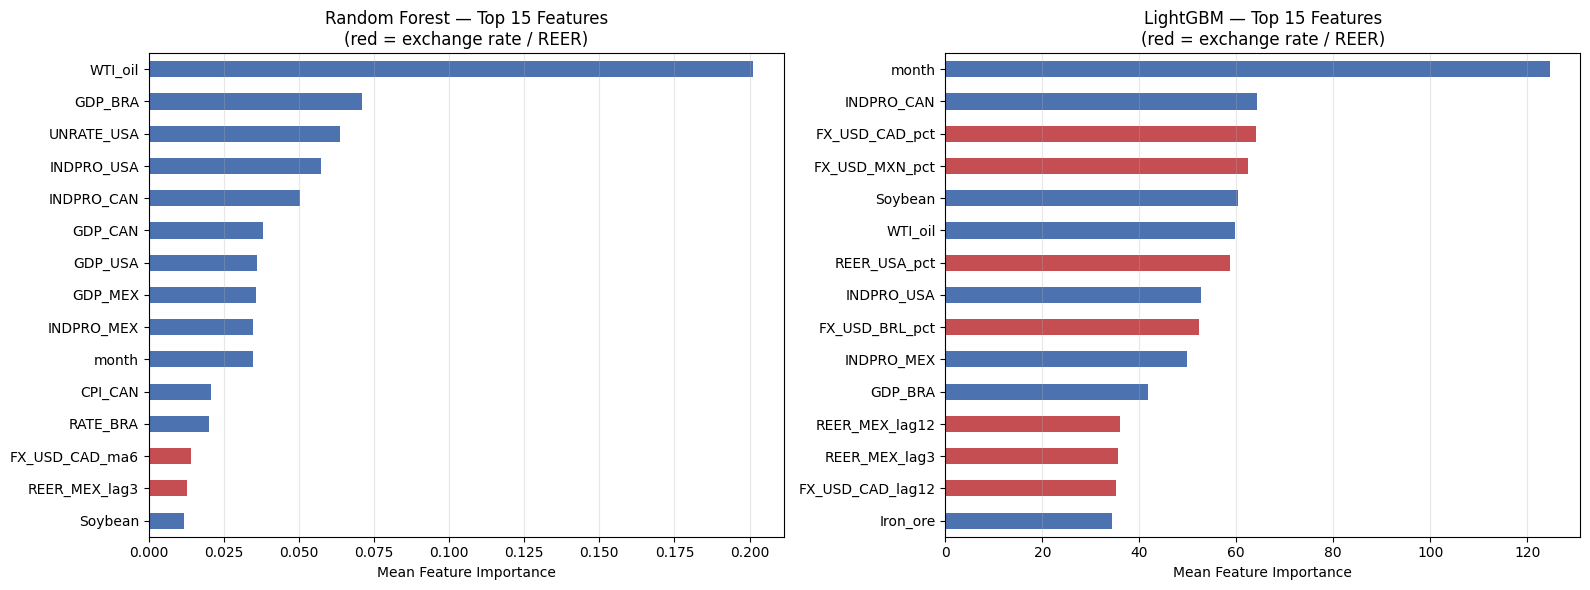

Saved: results/figures/evaluation/feature_importance_top15.png


In [67]:
# --- Plot Top 15 feature importances side by side ---
# Exchange rate and REER columns highlighted in red
fx_reer_cols = [c for c in feature_cols
                if any(fx in c for fx in FX_COLS + REER_COLS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, imp, title in zip(axes,
                           [rf_imp_mean.head(15), lgbm_imp_mean.head(15)],
                           ['Random Forest', 'LightGBM']):
    colors = ['#C44E52' if c in fx_reer_cols else '#4C72B0' for c in imp.index]
    imp[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
    ax.set_title(f'{title} — Top 15 Features\n(red = exchange rate / REER)', fontsize=12)
    ax.set_xlabel('Mean Feature Importance')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGS / 'feature_importance_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/feature_importance_top15.png')

---
## 6. SHAP Analysis

SHAP (SHapley Additive exPlanations) goes beyond feature importance:
- **Direction**: does a higher USD/BRL increase or decrease trade?
- **Magnitude**: by how much, on average?
- **Non-linearity**: does the effect change at different exchange rate levels?

This is the **core answer** to the thesis research question.

We compute SHAP values on the **test set (2022–2024)** for both Random Forest and LightGBM.
Comparing the two reveals whether different algorithms attribute importance to exchange rate variables in the same way.

> Install shap if needed: `pip install shap`

In [68]:
# --- Helper: get X_test for one series ---
def get_X_test(df, target):
    feat_cols  = get_feature_cols(df)
    log_target = 'log_' + target
    clean = df[feat_cols + [log_target]].dropna()
    X = clean[feat_cols]
    return X[X.index >= TEST_START]

# --- Compute SHAP values for all 24 RF models ---
shap_rf_values = {}  # (iso, target) -> ndarray (36, 73)
shap_rf_X_test = {}  # (iso, target) -> DataFrame

for iso in PARTNERS:
    df = datasets[iso]
    for target in TARGETS:
        model  = rf_models[(iso, target)]
        X_test = get_X_test(df, target)
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)
        shap_rf_values[(iso, target)] = shap_vals
        shap_rf_X_test[(iso, target)] = X_test
        print(f'SHAP RF: {iso} {target} -> shape={shap_vals.shape}')

print('\nAll SHAP values computed.')

SHAP RF: CAN exports_total -> shape=(36, 73)
SHAP RF: CAN exports_commodities -> shape=(36, 73)
SHAP RF: CAN exports_manufactured_goods -> shape=(36, 73)
SHAP RF: CAN exports_high-tech -> shape=(36, 73)
SHAP RF: CAN imports_total -> shape=(36, 73)
SHAP RF: CAN imports_commodities -> shape=(36, 73)
SHAP RF: CAN imports_manufactured_goods -> shape=(36, 73)
SHAP RF: CAN imports_high-tech -> shape=(36, 73)
SHAP RF: MEX exports_total -> shape=(36, 73)
SHAP RF: MEX exports_commodities -> shape=(36, 73)
SHAP RF: MEX exports_manufactured_goods -> shape=(36, 73)
SHAP RF: MEX exports_high-tech -> shape=(36, 73)
SHAP RF: MEX imports_total -> shape=(36, 73)
SHAP RF: MEX imports_commodities -> shape=(36, 73)
SHAP RF: MEX imports_manufactured_goods -> shape=(36, 73)
SHAP RF: MEX imports_high-tech -> shape=(36, 73)
SHAP RF: BRA exports_total -> shape=(36, 73)
SHAP RF: BRA exports_commodities -> shape=(36, 73)
SHAP RF: BRA exports_manufactured_goods -> shape=(36, 73)
SHAP RF: BRA exports_high-tech -> 

In [56]:
# --- Compute SHAP values for all 24 LightGBM models ---
shap_lgbm_values = {}  # (iso, target) -> ndarray (36, 73)
shap_lgbm_X_test = {}  # (iso, target) -> DataFrame

for iso in PARTNERS:
    df = datasets[iso]
    for target in TARGETS:
        model  = lgbm_models[(iso, target)]
        X_test = get_X_test(df, target)
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)
        shap_lgbm_values[(iso, target)] = shap_vals
        shap_lgbm_X_test[(iso, target)] = X_test
        print(f'SHAP LGBM: {iso} {target} -> shape={shap_vals.shape}')

print('\nAll LightGBM SHAP values computed.')

SHAP LGBM: CAN exports_total -> shape=(36, 73)
SHAP LGBM: CAN exports_commodities -> shape=(36, 73)
SHAP LGBM: CAN exports_manufactured_goods -> shape=(36, 73)
SHAP LGBM: CAN exports_high-tech -> shape=(36, 73)
SHAP LGBM: CAN imports_total -> shape=(36, 73)
SHAP LGBM: CAN imports_commodities -> shape=(36, 73)
SHAP LGBM: CAN imports_manufactured_goods -> shape=(36, 73)
SHAP LGBM: CAN imports_high-tech -> shape=(36, 73)
SHAP LGBM: MEX exports_total -> shape=(36, 73)
SHAP LGBM: MEX exports_commodities -> shape=(36, 73)
SHAP LGBM: MEX exports_manufactured_goods -> shape=(36, 73)
SHAP LGBM: MEX exports_high-tech -> shape=(36, 73)
SHAP LGBM: MEX imports_total -> shape=(36, 73)
SHAP LGBM: MEX imports_commodities -> shape=(36, 73)
SHAP LGBM: MEX imports_manufactured_goods -> shape=(36, 73)
SHAP LGBM: MEX imports_high-tech -> shape=(36, 73)
SHAP LGBM: BRA exports_total -> shape=(36, 73)
SHAP LGBM: BRA exports_commodities -> shape=(36, 73)
SHAP LGBM: BRA exports_manufactured_goods -> shape=(36, 

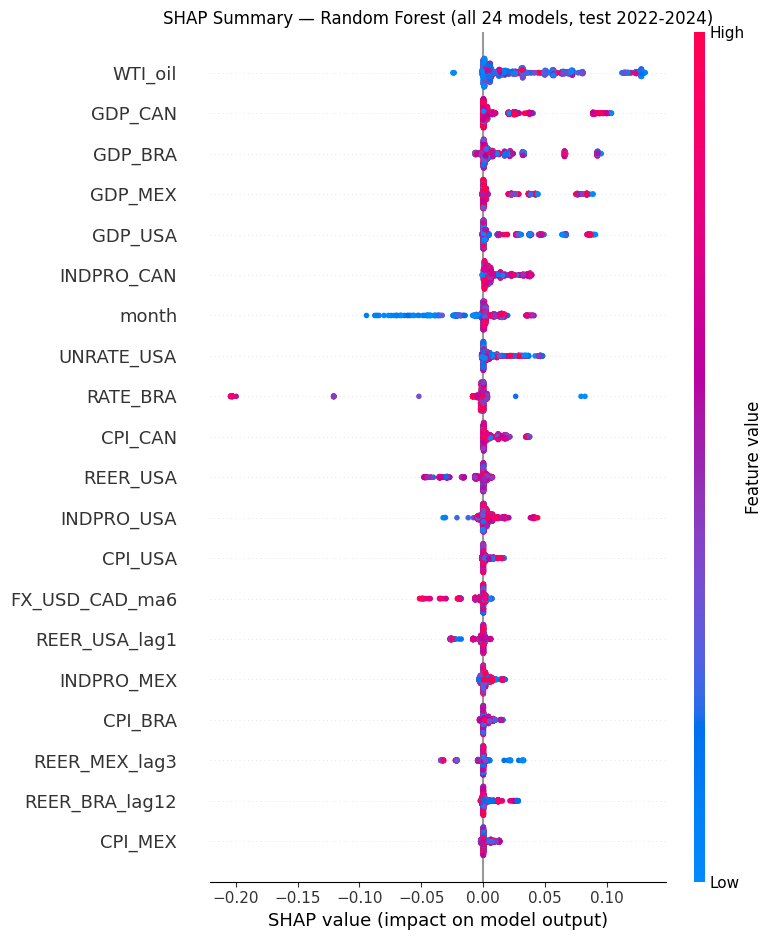

Saved: results/figures/evaluation/shap_rf_summary.png


In [69]:
# --- SHAP summary plot: all 24 RF models aggregated ---
# Each dot = one test observation from one model
# Color = feature value (blue=low, red=high)
# X axis = SHAP value (positive = pushed prediction higher)

all_shap = np.vstack([shap_rf_values[(iso, t)] for iso in PARTNERS for t in TARGETS])
all_X    = pd.concat([shap_rf_X_test[(iso, t)] for iso in PARTNERS for t in TARGETS])

plt.figure(figsize=(10, 10))
shap.summary_plot(all_shap, all_X, max_display=20, show=False)
plt.title('SHAP Summary — Random Forest (all 24 models, test 2022-2024)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'shap_rf_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/shap_rf_summary.png')

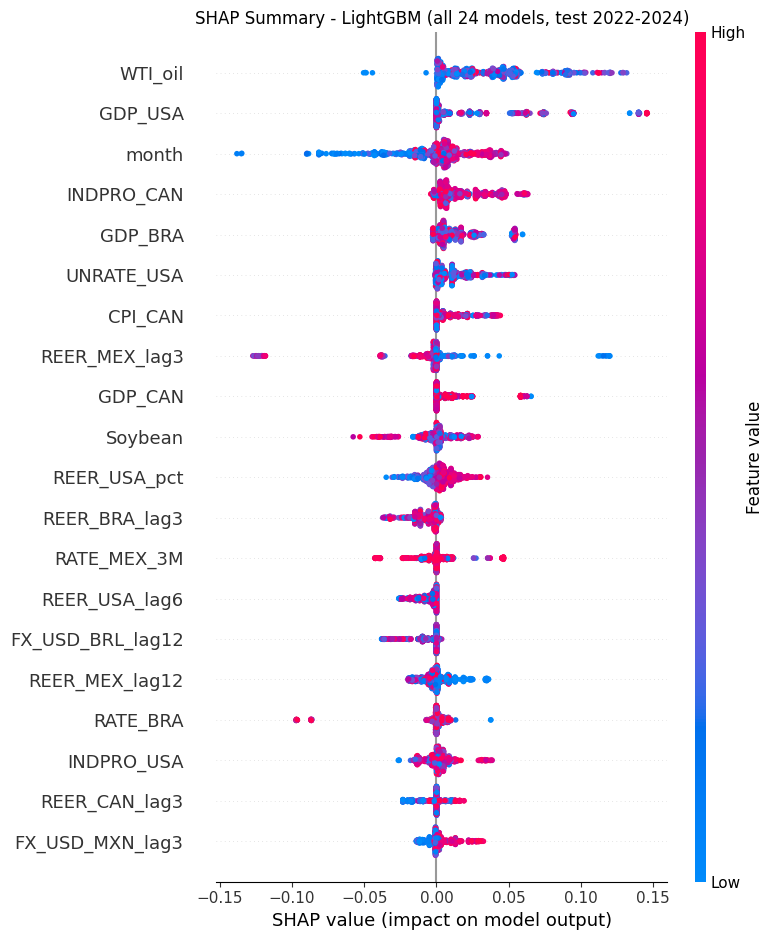

Saved: results/figures/evaluation/shap_lgbm_summary.png


In [58]:
# --- SHAP summary plot: all 24 LightGBM models aggregated ---
all_shap_lgbm = np.vstack([shap_lgbm_values[(iso, t)] for iso in PARTNERS for t in TARGETS])
all_X_lgbm    = pd.concat([shap_lgbm_X_test[(iso, t)] for iso in PARTNERS for t in TARGETS])

plt.figure(figsize=(10, 10))
shap.summary_plot(all_shap_lgbm, all_X_lgbm, max_display=20, show=False)
plt.title('SHAP Summary - LightGBM (all 24 models, test 2022-2024)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'shap_lgbm_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/shap_lgbm_summary.png')

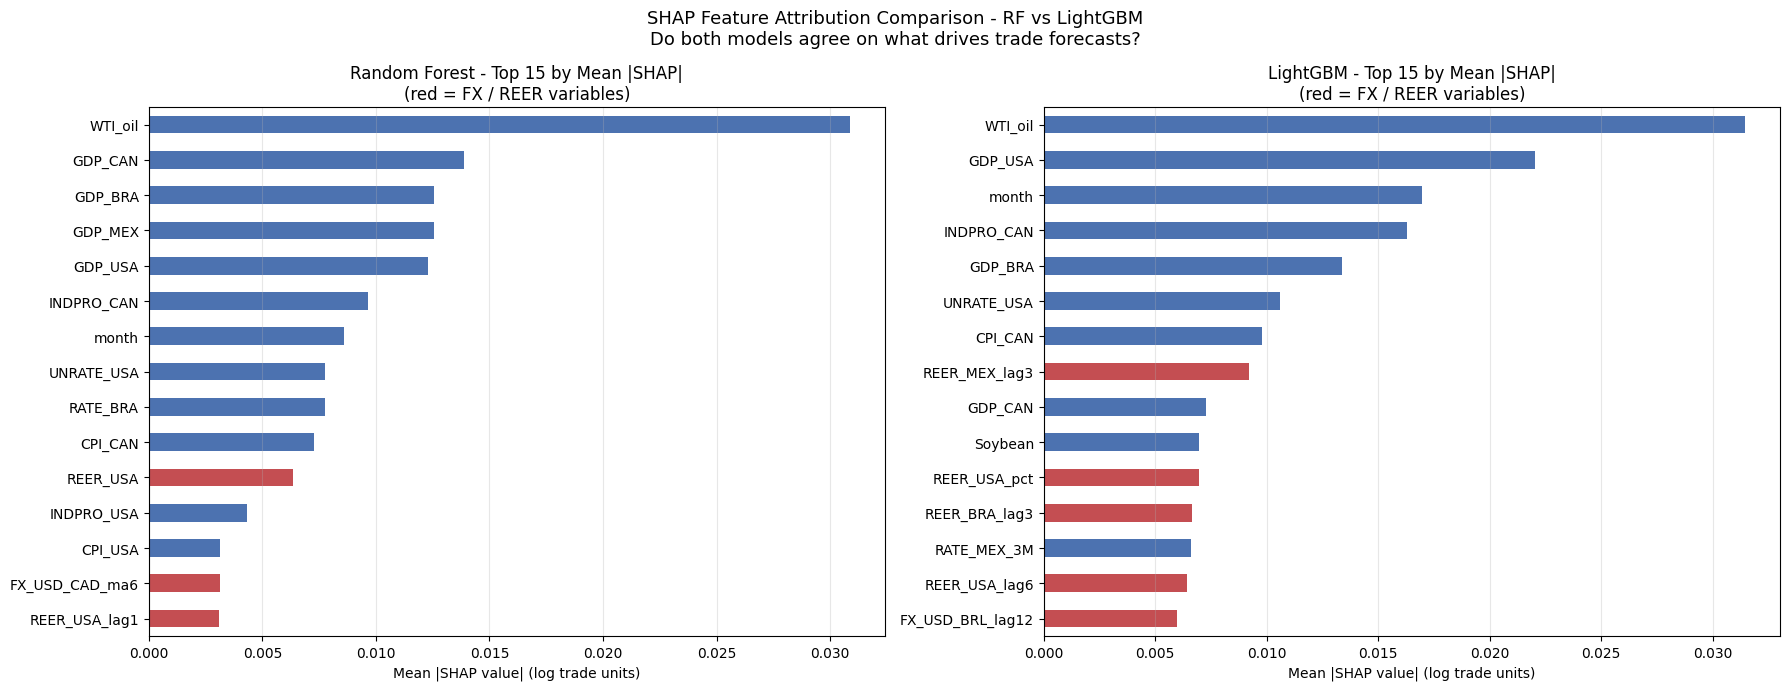

Saved: results/figures/evaluation/shap_comparison_rf_lgbm.png


In [70]:
# --- Mean |SHAP| per feature: RF vs LightGBM side by side ---
# Key comparison: do both models agree on which variables matter most?
def mean_abs_shap(shap_dict, X_dict):
    all_s = np.vstack([shap_dict[(iso, t)] for iso in PARTNERS for t in TARGETS])
    all_X = pd.concat([X_dict[(iso, t)] for iso in PARTNERS for t in TARGETS])
    return pd.Series(np.abs(all_s).mean(axis=0), index=all_X.columns).sort_values(ascending=False)

rf_shap_mean   = mean_abs_shap(shap_rf_values, shap_rf_X_test)
lgbm_shap_mean = mean_abs_shap(shap_lgbm_values, shap_lgbm_X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, shap_mean, title in zip(
        axes,
        [rf_shap_mean.head(15), lgbm_shap_mean.head(15)],
        ['Random Forest', 'LightGBM']):
    colors = ['#C44E52' if any(fx in c for fx in FX_COLS + REER_COLS) else '#4C72B0'
              for c in shap_mean.index]
    shap_mean[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
    ax.set_title(f'{title} - Top 15 by Mean |SHAP|\n(red = FX / REER variables)', fontsize=12)
    ax.set_xlabel('Mean |SHAP value| (log trade units)')
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('SHAP Feature Attribution Comparison - RF vs LightGBM\n'
             'Do both models agree on what drives trade forecasts?', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'shap_comparison_rf_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/shap_comparison_rf_lgbm.png')

---
## 7. Exchange Rate Focus

Zoom in on FX and REER variables.

**SHAP dependence plot:** shows how the model's prediction changes as the exchange rate changes.  
- X axis = exchange rate value  
- Y axis = SHAP contribution (positive = predicted more trade; negative = less trade)  
- Expected sign: USD appreciation (FX rises) → exports fall (negative SHAP) → imports rise (positive SHAP)

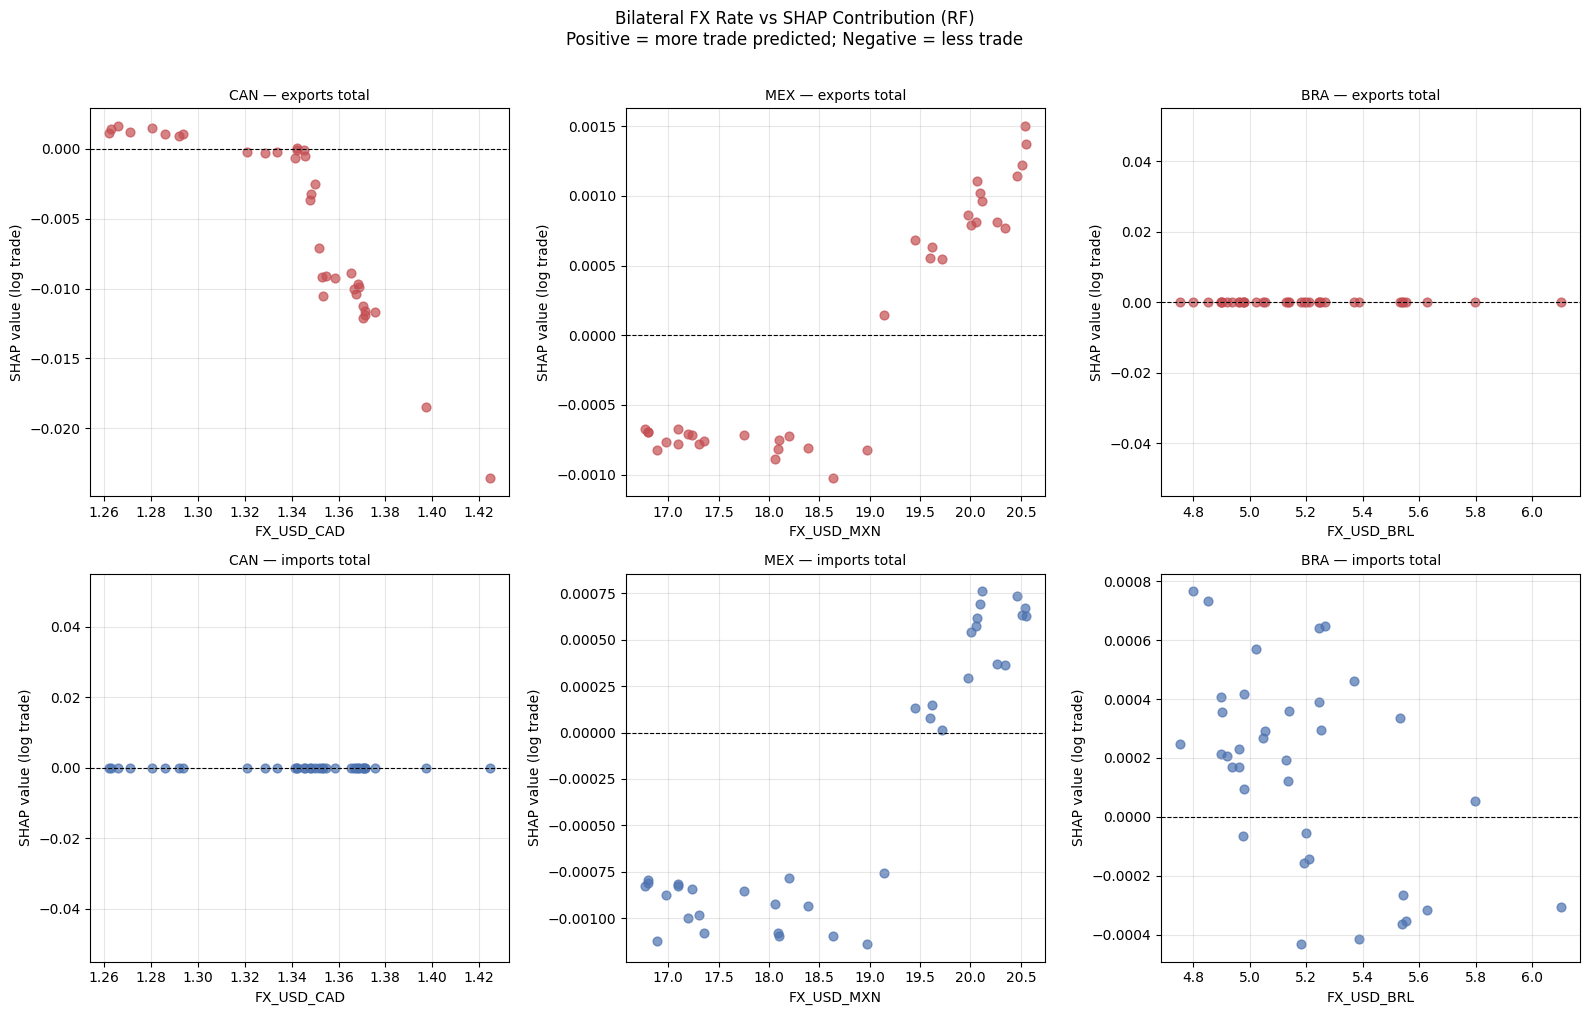

Saved: results/figures/evaluation/shap_fx_dependence.png


In [71]:
# --- SHAP dependence plots: bilateral FX rate for exports_total and imports_total ---
fx_var_map = {'CAN': 'FX_USD_CAD', 'MEX': 'FX_USD_MXN', 'BRA': 'FX_USD_BRL'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row_idx, target in enumerate(['exports_total', 'imports_total']):
    for col_idx, iso in enumerate(PARTNERS):
        ax = axes[row_idx, col_idx]
        fx_col = fx_var_map[iso]

        shap_vals = shap_rf_values[(iso, target)]
        X_test    = shap_rf_X_test[(iso, target)]

        feat_list = list(X_test.columns)
        if fx_col in feat_list:
            fx_idx   = feat_list.index(fx_col)
            fx_vals  = X_test[fx_col].values
            shap_fx  = shap_vals[:, fx_idx]

            color = '#C44E52' if 'exports' in target else '#4C72B0'
            ax.scatter(fx_vals, shap_fx, alpha=0.7, s=40, color=color)
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
            ax.set_xlabel(fx_col)
            ax.set_ylabel('SHAP value (log trade)')
            ax.set_title(f'{iso} — {target.replace("_", " ")}', fontsize=10)
            ax.grid(alpha=0.3)

fig.suptitle('Bilateral FX Rate vs SHAP Contribution (RF)\nPositive = more trade predicted; Negative = less trade',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'shap_fx_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/shap_fx_dependence.png')

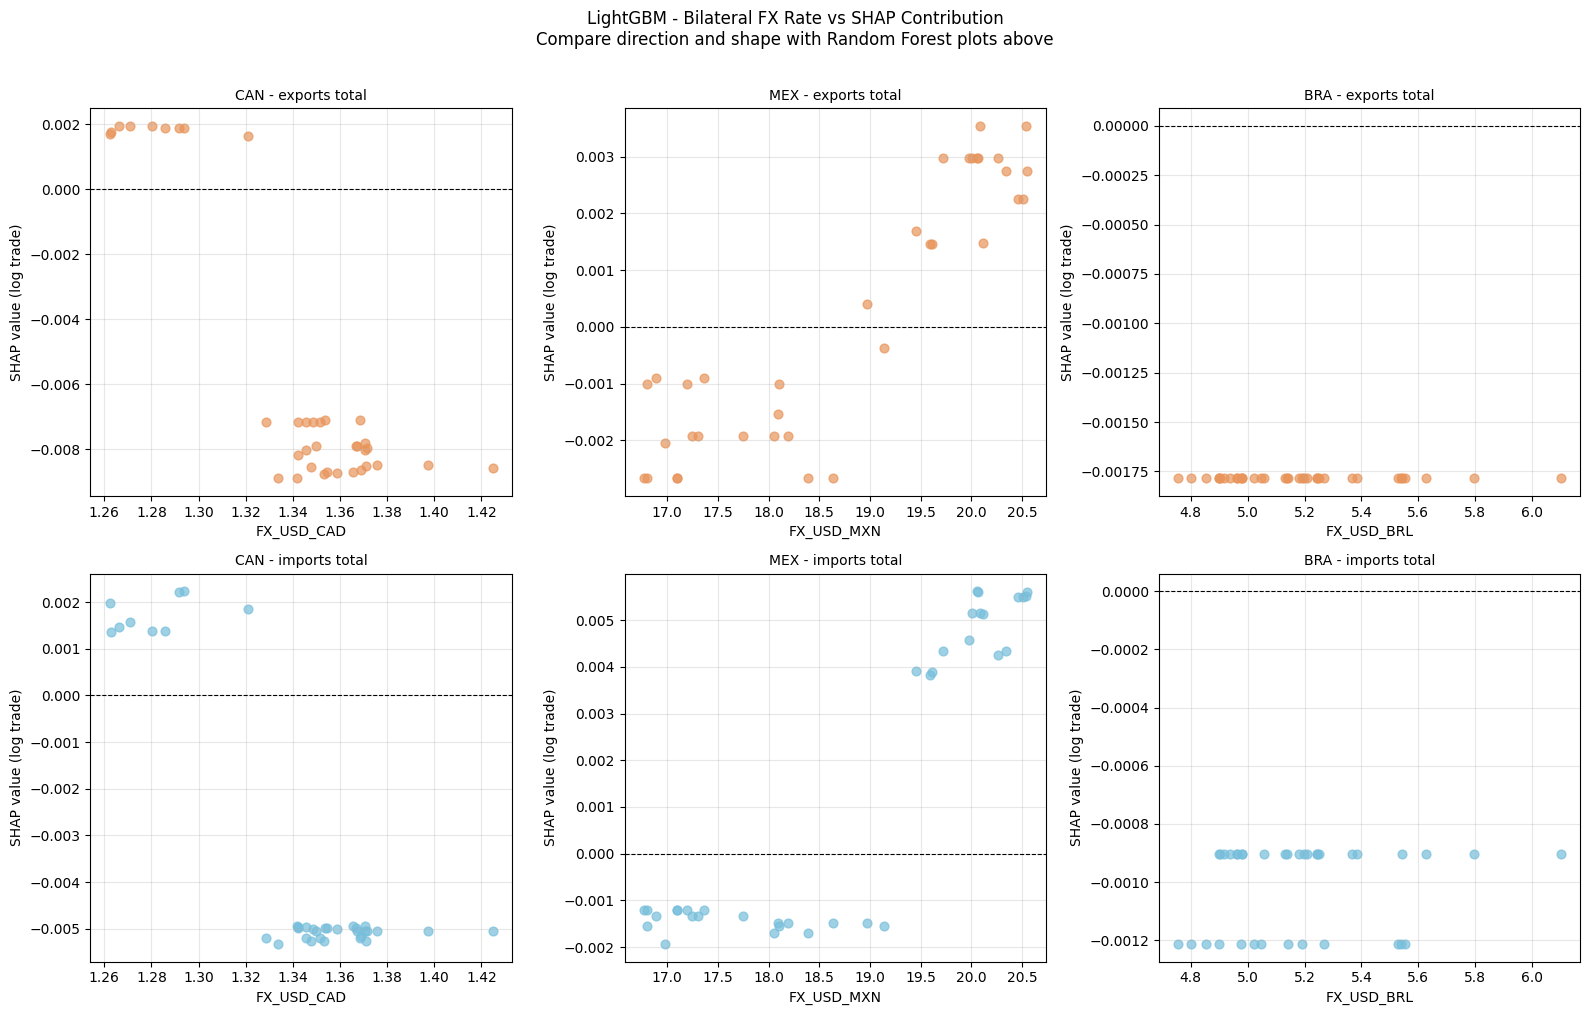

Saved: results/figures/evaluation/shap_lgbm_fx_dependence.png


In [61]:
# --- SHAP FX dependence plots: LightGBM (compare direction with RF above) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for row_idx, target in enumerate(['exports_total', 'imports_total']):
    for col_idx, iso in enumerate(PARTNERS):
        ax     = axes[row_idx, col_idx]
        fx_col = fx_var_map[iso]

        shap_vals = shap_lgbm_values[(iso, target)]
        X_test    = shap_lgbm_X_test[(iso, target)]
        feat_list = list(X_test.columns)

        if fx_col in feat_list:
            fx_idx  = feat_list.index(fx_col)
            fx_vals = X_test[fx_col].values
            shap_fx = shap_vals[:, fx_idx]

            color = '#E8945A' if 'exports' in target else '#77BEDB'
            ax.scatter(fx_vals, shap_fx, alpha=0.7, s=40, color=color)
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
            ax.set_xlabel(fx_col)
            ax.set_ylabel('SHAP value (log trade)')
            ax.set_title(f'{iso} - {target.replace("_", " ")}', fontsize=10)
            ax.grid(alpha=0.3)

fig.suptitle('LightGBM - Bilateral FX Rate vs SHAP Contribution\n'
             'Compare direction and shape with Random Forest plots above',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'shap_lgbm_fx_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/shap_lgbm_fx_dependence.png')

---
## 8. ARIMA vs ML Gap — What Do Exchange Rate Features Add?

ARIMA uses **only the series history** — no knowledge of exchange rates.  
RF and LightGBM use **73 features including exchange rates**.

The MAPE gap between ARIMA and best ML model per series is a proxy for:
> *How much predictive value do the exchange rate and macro features add beyond the series own history?*

Larger gap = exchange rate features explain more of the trade variation in that series.

In [72]:
# --- MAPE gap: ARIMA vs best ML per series ---
df_arima_m = (df_all[df_all['algorithm'] == 'ARIMA']
              [['country', 'target', 'MAPE']]
              .rename(columns={'MAPE': 'MAPE_ARIMA'}))
df_ml_best = (df_all[df_all['algorithm'] != 'ARIMA']
              .groupby(['country', 'target'])['MAPE']
              .min().reset_index()
              .rename(columns={'MAPE': 'MAPE_best_ML'}))

df_gap = df_arima_m.merge(df_ml_best, on=['country', 'target'])
df_gap['gap_pp']  = (df_gap['MAPE_ARIMA'] - df_gap['MAPE_best_ML']).round(4)
df_gap['pct_improvement'] = (df_gap['gap_pp'] / df_gap['MAPE_ARIMA'] * 100).round(1)
df_gap = df_gap.sort_values('gap_pp', ascending=False)

print('=== MAPE Gap: ARIMA vs Best ML Model ===')
print('Positive gap = ML is better; larger = exchange rate features helped more')
print()
print(df_gap.to_string(index=False))
print()
print(f'Average gap: {df_gap["gap_pp"].mean():.4f} pp ({df_gap["pct_improvement"].mean():.1f}% reduction)')

=== MAPE Gap: ARIMA vs Best ML Model ===
Positive gap = ML is better; larger = exchange rate features helped more

country                     target  MAPE_ARIMA  MAPE_best_ML  gap_pp  pct_improvement
    CAN          imports_high-tech      3.4792        0.9958  2.4834             71.4
    BRA        exports_commodities      2.9213        0.8820  2.0393             69.8
    MEX          imports_high-tech      3.0479        1.1608  1.8871             61.9
    BRA              imports_total      3.2470        1.3938  1.8532             57.1
    CAN          exports_high-tech      2.3606        0.7085  1.6521             70.0
    CAN exports_manufactured_goods      1.8177        0.6453  1.1724             64.5
    MEX              imports_total      1.8012        1.0021  0.7991             44.4
    BRA exports_manufactured_goods      1.4692        0.6937  0.7755             52.8
    BRA imports_manufactured_goods      1.9680        1.2345  0.7335             37.3
    BRA              expo

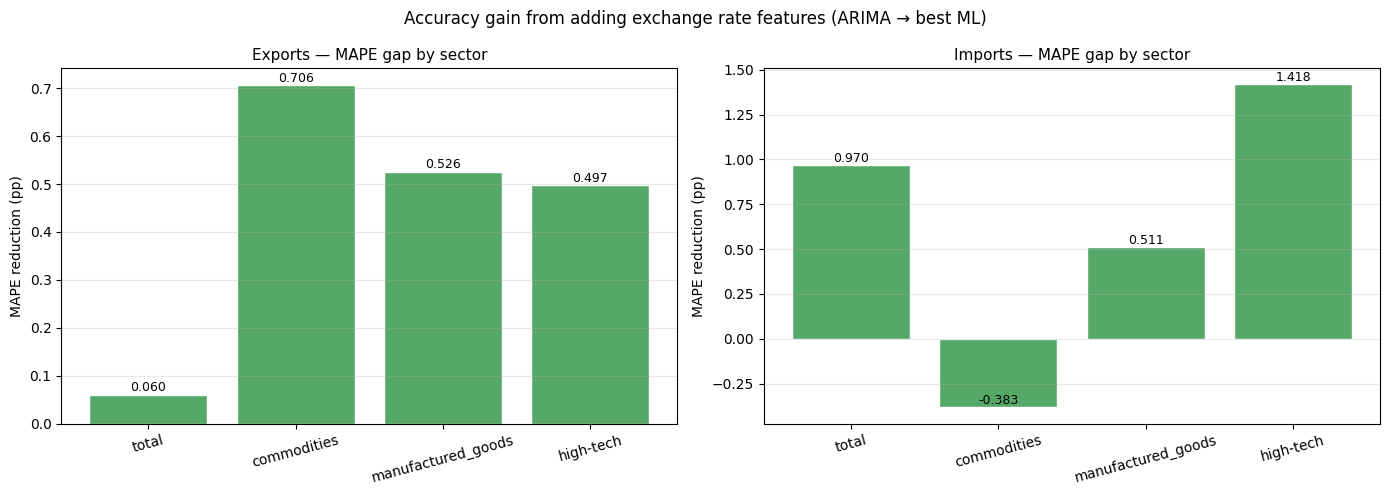

Saved: results/figures/evaluation/arima_ml_gap_by_sector.png


In [63]:
# --- Plot: gap by sector ---
sectors    = ['total', 'commodities', 'manufactured_goods', 'high-tech']
directions = ['exports', 'imports']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, direction in zip(axes, directions):
    vals = []
    for sector in sectors:
        target = f'{direction}_{sector}'
        vals.append(df_gap[df_gap['target'] == target]['gap_pp'].mean())

    bars = ax.bar(sectors, vals, color='#55A868', edgecolor='white')
    ax.set_title(f'{direction.capitalize()} — MAPE gap by sector', fontsize=11)
    ax.set_ylabel('MAPE reduction (pp)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Accuracy gain from adding exchange rate features (ARIMA → best ML)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'arima_ml_gap_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/arima_ml_gap_by_sector.png')

---
## 9. Sector Sensitivity to Exchange Rate

Which sectors are most sensitive to exchange rate movements?

Proxy: **mean absolute SHAP value** of FX and REER variables for each series.  
Higher value = exchange rate changes explain more of the prediction variance in that sector.

In [73]:
# --- FX sensitivity: average of RF and LightGBM SHAP ---
sensitivity = []

for iso in PARTNERS:
    for target in TARGETS:
        feat_list = list(shap_rf_X_test[(iso, target)].columns)
        fx_idx    = [k for k, c in enumerate(feat_list)
                     if any(fx in c for fx in FX_COLS + REER_COLS)]

        sens_rf   = float(np.abs(shap_rf_values[(iso, target)][:, fx_idx]).mean())
        sens_lgbm = float(np.abs(shap_lgbm_values[(iso, target)][:, fx_idx]).mean())

        sensitivity.append({
            'country':        iso,
            'target':         target,
            'fx_sens_RF':     round(sens_rf,              6),
            'fx_sens_LGBM':   round(sens_lgbm,            6),
            'fx_sensitivity': round((sens_rf + sens_lgbm) / 2, 6),
        })

df_sens = pd.DataFrame(sensitivity).sort_values('fx_sensitivity', ascending=False)

print('=== Exchange Rate Sensitivity by Series (mean |SHAP| of FX+REER variables) ===')
print('Averaged across Random Forest and LightGBM')
print()
print(df_sens.to_string(index=False))

=== Exchange Rate Sensitivity by Series (mean |SHAP| of FX+REER variables) ===
Averaged across Random Forest and LightGBM

country                     target  fx_sens_RF  fx_sens_LGBM  fx_sensitivity
    BRA imports_manufactured_goods    0.002109      0.006637        0.004373
    BRA        exports_commodities    0.000374      0.006869        0.003622
    MEX          imports_high-tech    0.001397      0.005188        0.003293
    BRA              imports_total    0.002267      0.003492        0.002880
    MEX              imports_total    0.000840      0.004918        0.002879
    BRA          exports_high-tech    0.001556      0.004131        0.002843
    MEX        exports_commodities    0.002243      0.003374        0.002808
    MEX imports_manufactured_goods    0.001553      0.003895        0.002724
    BRA              exports_total    0.000047      0.004898        0.002472
    MEX              exports_total    0.001017      0.003379        0.002198
    BRA          imports_high-

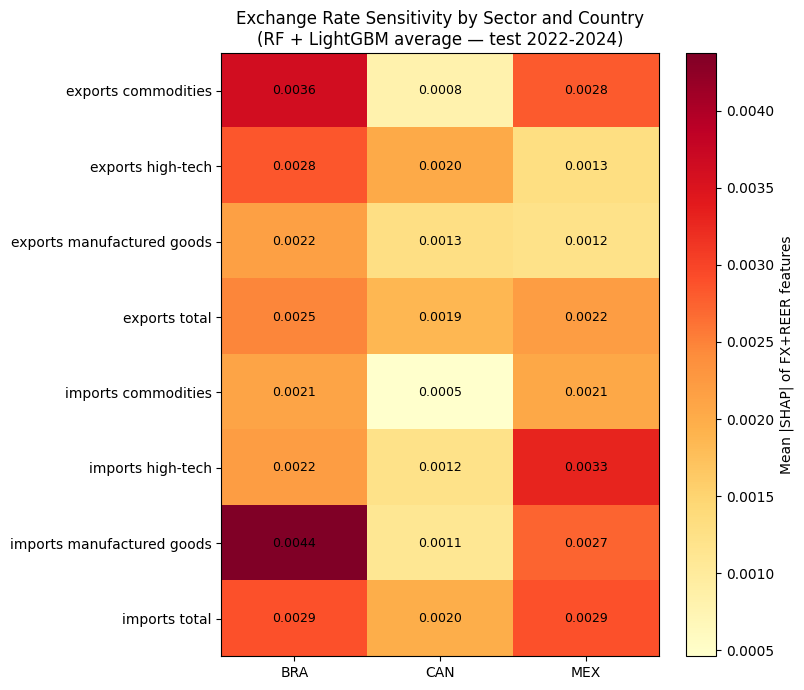

Saved: results/figures/evaluation/fx_sensitivity_heatmap.png


In [65]:
# --- Heatmap: FX sensitivity by country x sector ---
pivot = df_sens.pivot_table(values='fx_sensitivity', index='target', columns='country')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean |SHAP| of FX+REER features')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([t.replace('_', ' ') for t in pivot.index])
ax.set_title('Exchange Rate Sensitivity by Sector and Country\n(RF + LightGBM average — test 2022-2024)', fontsize=12)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.4f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'fx_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/figures/evaluation/fx_sensitivity_heatmap.png')

---
## 10. Summary for Thesis

In [74]:
print('=== THESIS SUMMARY — KEY FINDINGS ===')
print()
print('1. OVERALL MODEL PERFORMANCE (MAPE, test 2022-2024):')
for algo, mape in df_all.groupby('algorithm')['MAPE'].mean().sort_values().items():
    print(f'   {algo:<15}: {mape:.2f}%')

print()
print('2. WINS PER SERIES (best MAPE):')
best = df_all.loc[df_all.groupby(['country','target'])['MAPE'].idxmin()]
for algo, n in best['algorithm'].value_counts().items():
    print(f'   {algo:<15}: {n}/24 series')

print()
print('3. EXCHANGE RATE FEATURES VALUE (ARIMA vs ML gap):')
print(f'   Mean MAPE reduction: {df_gap["gap_pp"].mean():.4f} pp ({df_gap["pct_improvement"].mean():.1f}%)')
print(f'   Series where ARIMA beats ML: {(df_gap["gap_pp"] < 0).sum()}/24')

print()
print('4. TOP 5 MOST FX-SENSITIVE SERIES:')
for _, r in df_sens.head(5).iterrows():
    print(f'   {r["country"]} {r["target"]:<35}: sensitivity={r["fx_sensitivity"]:.5f}')

print()
print('Figures saved to: results/figures/evaluation/')
print('Ready for thesis Results and Discussion sections.')

=== THESIS SUMMARY — KEY FINDINGS ===

1. OVERALL MODEL PERFORMANCE (MAPE, test 2022-2024):
   RandomForest   : 0.94%
   LightGBM       : 1.03%
   ARIMA          : 1.41%

2. WINS PER SERIES (best MAPE):
   RandomForest   : 9/24 series
   ARIMA          : 8/24 series
   LightGBM       : 7/24 series

3. EXCHANGE RATE FEATURES VALUE (ARIMA vs ML gap):
   Mean MAPE reduction: 0.5384 pp (10.9%)
   Series where ARIMA beats ML: 8/24

4. TOP 5 MOST FX-SENSITIVE SERIES:
   BRA imports_manufactured_goods         : sensitivity=0.00437
   BRA exports_commodities                : sensitivity=0.00362
   MEX imports_high-tech                  : sensitivity=0.00329
   BRA imports_total                      : sensitivity=0.00288
   MEX imports_total                      : sensitivity=0.00288

Figures saved to: results/figures/evaluation/
Ready for thesis Results and Discussion sections.
